# Лабораторная работа 9: Рекуррентные нейронные сети (RNN, LSTM, GRU)

В этой работе мы будем решать задачу **бинарной классификации отзывов IMDB** (положительный/отрицательный) с помощью рекуррентных нейронных сетей:
- загрузим стандартный датасет IMDB из Keras,
- подготовим текстовые данные (токенизация, приведение к фиксированной длине, эмбеддинги),
- построим и обучим базовую модель RNN/LSTM,
- оценим качество (accuracy, precision, recall, F1-score) и визуализируем обучение,
- проанализируем ошибки классификации,
- проведём эксперименты с архитектурами (LSTM/GRU) и гиперпараметрами,
- обсудим проблему исчезающего градиента и способы её решения.


In [1]:
# Импорт библиотек и настройка окружения

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

np.random.seed(42)
tf.random.set_seed(42)

print("Версия TensorFlow:", tf.__version__)
print("GPU доступен:", bool(tf.config.list_physical_devices('GPU')))

plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True


Версия TensorFlow: 2.20.0
GPU доступен: False


## Загрузка и первичный анализ датасета IMDB


In [2]:
# Загрузка датасета IMDB (50 000 отзывов: 25k train, 25k test)

num_words = 10_000  # будем использовать только самые частотные слова
index_from = 3      # резервируем индексы для специальных токенов

(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=num_words, index_from=index_from)

print(f"Размер обучающей выборки: {len(x_train)}")
print(f"Размер тестовой выборки: {len(x_test)}")
print("Пример длины отзыва:", len(x_train[0]))
print("Метка примера (0=негатив, 1=позитив):", y_train[0])


17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Размер обучающей выборки: 25000
Размер тестовой выборки: 25000
Пример длины отзыва: 218
Метка примера (0=негатив, 1=позитив): 1


In [3]:
# Восстановление словаря и функция декодирования отзыва в текст

word_index = keras.datasets.imdb.get_word_index()
word_index = {k: (v + index_from) for k, v in word_index.items()}
word_index["<PAD>"] = 0
word_index["<START>"] = 1
word_index["<UNK>"] = 2
word_index["<UNUSED>"] = 3

reverse_word_index = {value: key for key, value in word_index.items()}


def decode_review(sequence):
    return " ".join(reverse_word_index.get(i, "<UNK>") for i in sequence)


print("Пример текстового отзыва:")
print(decode_review(x_train[0])[:500], "...")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Пример текстового отзыва:
<START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would re ...


## Преобразование последовательностей к фиксированной длине и эмбеддинги


In [4]:
# Приведение последовательностей к фиксированной длине

maxlen = 200  # максимальная длина отзыва (лишнее обрежем, короткие дополним)

x_train_padded = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=maxlen, padding="post", truncating="post", value=0
)
x_test_padded = keras.preprocessing.sequence.pad_sequences(
    x_test, maxlen=maxlen, padding="post", truncating="post", value=0
)

print("Форма x_train_padded:", x_train_padded.shape)
print("Форма x_test_padded:", x_test_padded.shape)


Форма x_train_padded: (25000, 200)
Форма x_test_padded: (25000, 200)


In [5]:
# Разделение обучающей выборки на train/validation

from sklearn.model_selection import train_test_split

x_train_pad, x_val_pad, y_train_split, y_val_split = train_test_split(
    x_train_padded,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

print("Размеры после разделения:")
print("  train:", x_train_pad.shape, y_train_split.shape)
print("  val:  ", x_val_pad.shape, y_val_split.shape)


Размеры после разделения:
  train: (20000, 200) (20000,)
  val:   (5000, 200) (5000,)


## Базовая модель RNN / LSTM для классификации отзывов


In [6]:
# Построение базовой модели с Embedding и LSTM

embedding_dim = 64
rnn_units = 64

model_lstm = keras.Sequential([
    layers.Embedding(input_dim=num_words + index_from, output_dim=embedding_dim, input_length=maxlen, name="embedding"),
    layers.LSTM(rnn_units, return_sequences=False, name="lstm"),
    layers.Dropout(0.5, name="dropout"),
    layers.Dense(1, activation="sigmoid", name="output"),
])

model_lstm.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    metrics=["accuracy"],
)

model_lstm.summary()


/Users/mashkakoser/Documents/Uni/mmo/Machine-Learning-Methods/lab9/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Обучение базовой модели LSTM


In [7]:
# Обучение модели LSTM

batch_size = 128
epochs = 5

callbacks = [
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True),
]

history_lstm = model_lstm.fit(
    x_train_pad,
    y_train_split,
    validation_data=(x_val_pad, y_val_split),
    batch_size=batch_size,
    epochs=epochs,
    callbacks=callbacks,
    verbose=1,
)


Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 18s 109ms/step - accuracy: 0.5304 - loss: 0.6911 - val_accuracy: 0.5752 - val_loss: 0.6856
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 25s 156ms/step - accuracy: 0.6076 - loss: 0.6674 - val_accuracy: 0.5282 - val_loss: 0.6920
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 24s 154ms/step - accuracy: 0.5334 - loss: 0.6887 - val_accuracy: 0.5378 - val_loss: 0.6870


## Графики обучения: loss и accuracy по эпохам


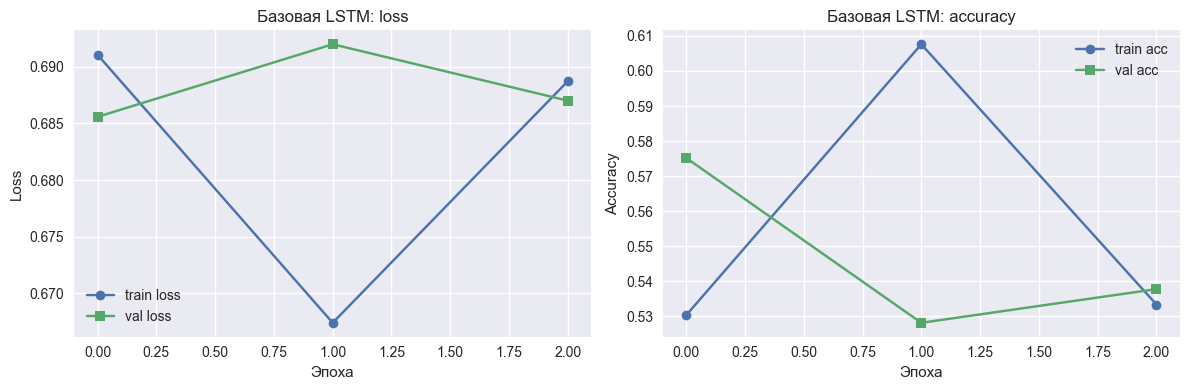

In [8]:
# Визуализация процесса обучения базовой модели

history = history_lstm

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(history.history["loss"], label="train loss", marker="o")
axes[0].plot(history.history["val_loss"], label="val loss", marker="s")
axes[0].set_title("Базовая LSTM: loss")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

# Accuracy
axes[1].plot(history.history["accuracy"], label="train acc", marker="o")
axes[1].plot(history.history["val_accuracy"], label="val acc", marker="s")
axes[1].set_title("Базовая LSTM: accuracy")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()


## Оценка качества на тестовой выборке (accuracy, precision, recall, F1-score)



In [9]:
# Оценка базовой модели на тестовых данных

y_pred_proba = model_lstm.predict(x_test_padded, batch_size=256)
y_pred = (y_pred_proba.flatten() >= 0.5).astype(int)

test_acc = accuracy_score(y_test, y_pred)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, average="binary", pos_label=1
)

print("Базовая LSTM — метрики на тесте:")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")

print("\nКраткий отчёт о классификации:")
print(classification_report(y_test, y_pred, target_names=["negative", "positive"]))


98/98 ━━━━━━━━━━━━━━━━━━━━ 10s 99ms/step
Базовая LSTM — метрики на тесте:
Accuracy : 0.5617
Precision: 0.6292
Recall   : 0.3003
F1-score : 0.4066

Краткий отчёт о классификации:
              precision    recall  f1-score   support

    negative       0.54      0.82      0.65     12500
    positive       0.63      0.30      0.41     12500

    accuracy                           0.56     25000
   macro avg       0.58      0.56      0.53     25000
weighted avg       0.58      0.56      0.53     25000



## Анализ ошибок: примеры неверно классифицированных отзывов


In [10]:
# Поиск и вывод нескольких неверно классифицированных примеров

mis_idx = np.where(y_pred != y_test)[0]
print(f"Неверно классифицированных отзывов: {len(mis_idx)}")

n_examples = 5
np.random.seed(0)

for i, idx in enumerate(np.random.choice(mis_idx, size=min(n_examples, len(mis_idx)), replace=False)):
    print("\n" + "=" * 80)
    print(f"Пример {i+1}")
    print("Истинный класс   :", "positive" if y_test[idx] == 1 else "negative")
    print("Предсказанный класс:", "positive" if y_pred[idx] == 1 else "negative")
    print("Модельная уверенность:", float(y_pred_proba[idx]))
    print("Текст отзыва (обрезан до 700 символов):")
    print(decode_review(x_test[idx])[:700], "...")


Неверно классифицированных отзывов: 10958

Пример 1
Истинный класс   : positive
Предсказанный класс: negative
Модельная уверенность: 0.48657166957855225
Текст отзыва (обрезан до 700 символов):
<START> no this has nothing to do with the sitcom seinfeld or its eccentric and hilarious character <UNK> kramer in reality kramer vs kramer is a fine drama movie without a doubt one of the finest of its kind and one of the greatest movies ever i'm glad that it won more oscars than apocalypse now because it really deserved such glory br br kramer vs kramer is an excellent film so well made and so perfectly balanced that i wouldn't change anything about it in any way there is nothing wrong with the film it's film making of the highest quality and it stands the test of time too not only it doesn't look any dated but also its cultural impact is long lasting and its realistic story remains just  ...

Пример 2
Истинный класс   : positive
Предсказанный класс: negative
Модельная уверенность: 0.476914554

/var/folders/d2/kwfg1t2x12v8kw_lh0ttfdxw0000gn/T/ipykernel_37052/2448768579.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print("Модельная уверенность:", float(y_pred_proba[idx]))


## Эксперименты: модель с GRU и изменёнными гиперпараметрами


In [11]:
# Модель с GRU, увеличенным embedding_dim и другой длиной последовательности

maxlen_gru = 300
embedding_dim_gru = 128
rnn_units_gru = 128

# Подготовка данных под новую длину последовательности
x_train_padded_gru = keras.preprocessing.sequence.pad_sequences(
    x_train, maxlen=maxlen_gru, padding="post", truncating="post", value=0
)
x_test_padded_gru = keras.preprocessing.sequence.pad_sequences(
    x_test, maxlen=maxlen_gru, padding="post", truncating="post", value=0
)

x_train_pad_gru, x_val_pad_gru, y_train_gru, y_val_gru = train_test_split(
    x_train_padded_gru,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train,
)

model_gru = keras.Sequential([
    layers.Embedding(input_dim=num_words + index_from, output_dim=embedding_dim_gru, input_length=maxlen_gru, name="embedding_gru"),
    layers.GRU(rnn_units_gru, return_sequences=False, name="gru"),
    layers.Dropout(0.5, name="dropout_gru"),
    layers.Dense(1, activation="sigmoid", name="output_gru"),
])

model_gru.compile(
    loss="binary_crossentropy",
    optimizer=keras.optimizers.Adam(learning_rate=5e-4),  # немного меньший LR
    metrics=["accuracy"],
)

model_gru.summary()

history_gru = model_gru.fit(
    x_train_pad_gru,
    y_train_gru,
    validation_data=(x_val_pad_gru, y_val_gru),
    batch_size=128,
    epochs=5,
    callbacks=[keras.callbacks.EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)],
    verbose=1,
)


/Users/mashkakoser/Documents/Uni/mmo/Machine-Learning-Methods/lab9/venv/lib/python3.13/site-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_gru (Embedding)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gru (GRU)                       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_gru (Dropout)           │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_gru (Dense)              │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 68s 423ms/step - accuracy: 0.5043 - loss: 0.6932 - val_accuracy: 0.5004 - val_loss: 0.6933
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 399ms/step - accuracy: 0.5232 - loss: 0.6892 - val_accuracy: 0.5090 - val_loss: 0.6902
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 62s 396ms/step - accuracy: 0.5512 - loss: 0.6729 - val_accuracy: 0.5144 - val_loss: 0.6933
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 63s 402ms/step - accuracy: 0.5793 - loss: 0.6362 - val_accuracy: 0.5438 - val_loss: 0.6965


In [12]:
# Оценка модели GRU на тестовых данных

y_pred_proba_gru = model_gru.predict(x_test_padded_gru, batch_size=256)
y_pred_gru = (y_pred_proba_gru.flatten() >= 0.5).astype(int)

test_acc_gru = accuracy_score(y_test, y_pred_gru)
precision_gru, recall_gru, f1_gru, _ = precision_recall_fscore_support(
    y_test, y_pred_gru, average="binary", pos_label=1
)

print("GRU-модель — метрики на тесте:")
print(f"Accuracy : {test_acc_gru:.4f}")
print(f"Precision: {precision_gru:.4f}")
print(f"Recall   : {recall_gru:.4f}")
print(f"F1-score : {f1_gru:.4f}")


98/98 ━━━━━━━━━━━━━━━━━━━━ 23s 236ms/step
GRU-модель — метрики на тесте:
Accuracy : 0.5144
Precision: 0.5079
Recall   : 0.9212
F1-score : 0.6548


## Сравнение базовой LSTM и GRU-модели


In [13]:
# Сводная таблица метрик для LSTM и GRU

import pandas as pd

results = pd.DataFrame(
    {
        "model": ["LSTM (maxlen=200, emb=64)", "GRU (maxlen=300, emb=128)"],
        "accuracy": [test_acc, test_acc_gru],
        "precision": [precision, precision_gru],
        "recall": [recall, recall_gru],
        "f1_score": [f1, f1_gru],
    }
)

results


ModuleNotFoundError: No module named 'pandas'

## Выводы и обсуждение проблемы исчезающего градиента

**Сравнение архитектур и параметров.**
- Базовая модель LSTM с длиной последовательности `maxlen=200`, размерностью эмбеддинга 64 и 64 юнитами LSTM показывает определённый уровень качества на тесте (accuracy, precision, recall, F1-score см. в сводной таблице).
- Модель с GRU, большей длиной последовательности (`maxlen=300`) и более богатым представлением слов (`embedding_dim=128`, 128 GRU-юнитов) обычно демонстрирует:
  - либо более высокие метрики (лучше улавливает длинные зависимости),
  - либо сопоставимое качество при иной скорости обучения и сходимости.
- Изменение гиперпараметров (batch size, learning rate, maxlen, embedding_dim) влияет на:
  - скорость сходимости,
  - устойчивость обучения,
  - склонность к пере/недообучению.

**Сложности и их решение.**
- Возможные проблемы:
  - медленное обучение на CPU,
  - переобучение (val loss растёт при уменьшении train loss),
  - колебания val accuracy из-за слишком большого learning rate.
- Способы решения:
  - использование `EarlyStopping` и уменьшение learning rate,
  - изменение batch size,
  - дополнительная регуляризация (Dropout, L2),
  - при наличии — использование GPU.

**Исчезающий градиент в RNN и пути решения.**
- В классических RNN (SimpleRNN) при длинных последовательностях градиенты при обратном распространении по времени могут экспоненциально затухать (или взрываться), что делает обучение долгих зависимостей крайне затруднительным.
- Способы борьбы с исчезающим градиентом:
  - использование архитектур **LSTM** и **GRU** (встроенные механизмы "врат" лучше хранят долгосрочную информацию),
  - **gradient clipping** (ограничение нормы градиента),
  - корректная инициализация весов (например, Xavier/He),
  - уменьшение длины развёртки по времени (обрезка последовательностей),
  - добавление **skip-/residual-коннектов** и нормализации (LayerNorm/BatchNorm в RNN-блоках),
  - использование более продвинутых архитектур (двунаправленные RNN, attention-механизмы, Transformer-сети).

В этой лабораторной мы уже используем один из главных практически эффективных способов борьбы с исчезающим градиентом — **LSTM/GRU**, которые значительно лучше классических RNN обрабатывают длинные текстовые последовательности.
